# Generate artificial clusters

Disclamer : Claude was use to generate code in this notebook. The code was reviewed by Emilien Schultz.

Sandbox notebook for producing synthetic Likert-style datasets with a known cluster structure, using `make_classification` so we can control how many features actually carry cluster signal and add label-side noise. See `GeneratingClusters.md` for the spec.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

## Parameters

Defaults match the `replic_830` baseline: 830 respondents, 23 Likert items, 4 classes.

In [72]:
@dataclass
class SimConfig:
    """
    Parameters for one synthetic-data scenario.
    Defaults match the `replic_830` baseline.
    """
    n_samples: int = 830            # respondents
    n_features: int = 23            # Likert items
    n_informative: int = 4          # features carrying real cluster signal
    n_redundant: int = 4            # linear combos of the informative features
    n_classes: int = 4              # B&D headline = 4 latent classes
    n_clusters_per_class: int = 1   # one Gaussian blob per class
    class_balance: tuple | None = None  # relative cluster sizes; None = equal.
                                        # proportions (0.4, 0.2, 0.2, 0.2) or
                                        # counts (400, 150, 150, 130) -- both
                                        # normalised internally. Length must
                                        # equal n_classes.
    flip_y: float = 0.01             # fraction of labels randomly flipped (Y noise)
    class_sep: float = 5.0         # larger = easier problem
    random_state: int = 0
    likert: bool = True            # set True to bin to {1..5}


cfg = SimConfig()

## Generate

In [73]:
def generate_clusters(cfg):
    # Class balance: None -> equal sizes; otherwise normalise the given
    # proportions / counts to weights that sum to 1 (as make_classification
    # expects). Length must match n_classes.
    weights = None
    if cfg.class_balance is not None:
        if len(cfg.class_balance) != cfg.n_classes:
            raise ValueError(
                f'class_balance has {len(cfg.class_balance)} entries '
                f'but n_classes={cfg.n_classes}')
        w = np.asarray(cfg.class_balance, dtype=float)
        weights = (w / w.sum()).tolist()

    X, y_true = make_classification(
        n_samples=cfg.n_samples,
        n_features=cfg.n_features,
        n_informative=cfg.n_informative,
        n_redundant=cfg.n_redundant,
        n_repeated=0,
        n_classes=cfg.n_classes,
        n_clusters_per_class=cfg.n_clusters_per_class,
        weights=weights,
        flip_y=cfg.flip_y,
        class_sep=cfg.class_sep,
        random_state=cfg.random_state,
    )
    if cfg.likert:
        col_min = X.min(axis=0)
        col_max = X.max(axis=0)
        scaled = (X - col_min) / np.where(col_max - col_min == 0, 1, col_max - col_min)
        X = np.clip(np.round(scaled * 4) + 1, 1, 5).astype(int)
    df = pd.DataFrame(X, columns=[f'V{i+1}' for i in range(cfg.n_features)])
    return df, y_true

df, y_true = generate_clusters(cfg)

print(f'shape: {df.shape}')
print('cluster sizes:')
print(pd.Series(y_true).value_counts().sort_index().to_string())
df.head()

shape: (830, 23)
cluster sizes:
0    208
1    211
2    205
3    206


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23
0,5,2,3,2,4,3,2,3,2,2,...,3,3,2,4,3,4,3,2,4,2
1,5,2,3,3,4,4,2,4,3,3,...,3,2,2,2,3,4,4,2,4,2
2,5,2,4,3,4,3,2,4,3,3,...,3,2,2,4,4,3,4,3,3,2
3,5,2,2,3,4,2,2,3,2,3,...,4,3,2,4,3,3,2,3,3,2
4,3,4,4,2,5,4,2,3,2,2,...,4,3,2,3,3,2,4,3,2,4


## 2D PCA projection

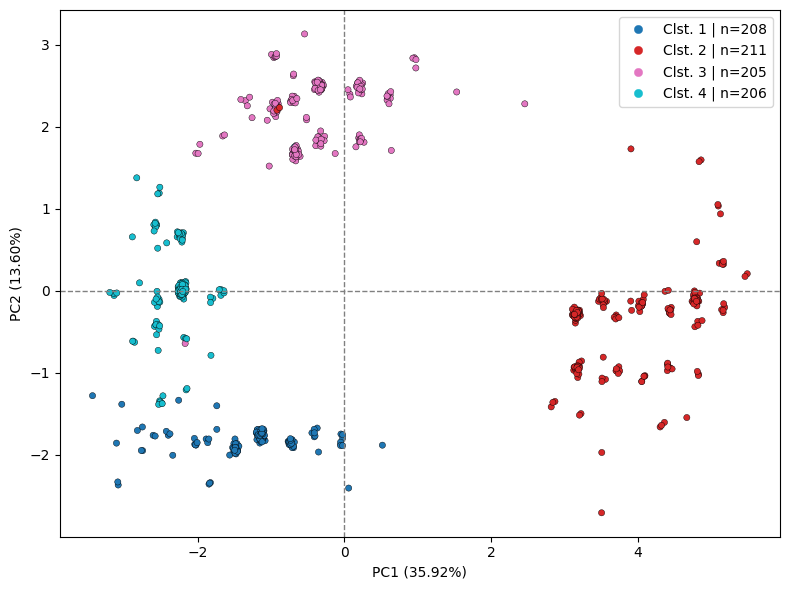

In [74]:
def plot_pca_projection(df, y_true):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(df)
    explained = pca.explained_variance_ratio_ * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        reduced[:, 0], reduced[:, 1],
        c=y_true, cmap='tab10', s=20, edgecolors='k', linewidths=0.3,
    )
    ax.axhline(0, color='grey', linestyle='dashed', linewidth=1)
    ax.axvline(0, color='grey', linestyle='dashed', linewidth=1)
    ax.set_xlabel(f'PC1 ({explained[0]:.2f}%)')
    ax.set_ylabel(f'PC2 ({explained[1]:.2f}%)')

    sizes = pd.Series(y_true).value_counts().sort_index()
    handles, _ = scatter.legend_elements()
    labels = [f'Clst. {k+1} | n={v}' for k, v in sizes.items()]
    ax.legend(handles, labels, title='')
    plt.tight_layout()
    plt.show()

plot_pca_projection(df, y_true)

## Test the pipeline on the synthetic data

Run `process_dataset` end-to-end on the generated frame to confirm the clustering robustness pipeline behaves on data with known ground truth. Uses light settings (`max_clust=10`, `gap_iters=50`, HDBSCAN off) so the sandbox stays interactive — bump to the headline values (`max_clust=16`, `gap_iters=500`, `run_hdbscan=True`) for production-grade runs.

The defaults now mirror `4_clustering.ipynb`: `msrt='categorical'` with `subtract_one=True`, which reindexes the 1..5 Likert columns to start at 0 as StepMix expects (the notebook's `data2004[var_list_n] - 1`). This assumes Likert output from the generator (`likert=True`, the default). For raw Gaussian features (`likert=False`), pass `msrt='continuous'` so the script standardizes them instead.

In [75]:
from process_dataset import process_dataset

# Defaults mirror 4_clustering.ipynb (msrt='categorical', subtract_one=True,
# standardize=True); only the light sandbox settings are overridden here.
result = process_dataset(
    df,
    max_clust=10,
    gap_iters=50,
    n_jobs=8,
    run_hdbscan=True,
)

Bootstrapping CVIs: 100%|██████████| 10400/10400 [02:02<00:00, 85.15it/s] 
/Users/emilien/Dropbox/CREST/Projets en cours/2026-Clustering/Scales-of-Nationalism/process_dataset.py:223: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  candidate_models = pd.concat(


## Model comparison

Best and second-best configurations per clustering validity index, built from `result['all_models']`. Distance-based algorithms (k-means / AHC / HDBSCAN) are ranked together; LCA is reported separately because on the real data it consistently scores worse.

- `*` flags models that yield unbalanced clusters — the largest cluster holds ≥ 90% of individuals (`unbalanced_ratio`), the others almost empty.
- For the **Silhouette (SL)**, **Calinski-Harabasz (CH)** and **Generalized Dunn (GD43)** scores, higher is better; for **Davies-Bouldin (DB)**, lower is better.

To populate the HDBSCAN rows, run `process_dataset(..., run_hdbscan=True)` above (the light sandbox settings turn it off).

In [76]:
from src.tooling import model_comparison_table

table = model_comparison_table(result['all_models'], n_samples=len(df))

(table
 .set_index(['Section', 'Clustering Validity Index'])
 .style
 .set_caption('Table 2. Model comparison: best and second-best model '
              'configurations by validity index and corresponding scores.'))